In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm import trange
import ot

In [3]:
torch.manual_seed(0)
np.random.seed(0)

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 512, bias=False)
        self.fc2 = nn.Linear(512, 10, bias=False)
        self.relu = nn.ReLU()
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = x.view(-1, 28*28)
        h = self.relu(self.fc1(x))
        out = self.fc2(h)
        return self.logsoftmax(out)

In [5]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
N = len(dataset)
half = N // 2
subsetA, subsetB = random_split(dataset, [half, N - half])
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=512)

In [6]:
def train_model(model, dataset, epochs=5, lr=1e-1, batch_size=128, verbose=True):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum = 0, dampening = 0 , weight_decay = 0)
    criterion = nn.NLLLoss()
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - loss: {running/len(loader.dataset):.4f}")
    return model

In [7]:
# print("Training Model A on subset A...")
# modelA = train_model(MLP(), subsetA)
# print("Training Model B on subset B...")
# modelB = train_model(MLP(), subsetB)
# print("Training Full Model on full training dataset")
# modelFull = train_model(MLP(), dataset)


# stateA = modelA.state_dict()
# stateB = modelB.state_dict()
# modelFull_state = modelFull.state_dict()


# torch.save(modelA.state_dict(), "modelA.pt")
# torch.save(modelB.state_dict(), "modelB.pt")
# torch.save(modelFull.state_dict(), "modelFull.pt")
# print("Saved modelA.pt, modelB.pt, and modelFull.pt")

In [8]:
modelA = MLP()
modelB= MLP()
modelFull = MLP()


modelA.load_state_dict(torch.load("modelA.pt"))
modelB.load_state_dict(torch.load("modelB.pt"))
modelFull.load_state_dict(torch.load("modelFull.pt"))

<All keys matched successfully>

In [9]:
stateA = modelA.state_dict()
stateB = modelB.state_dict()
modelFull_state = modelFull.state_dict()

In [33]:
def evaluate_model_state_dict(state_dict, model_cls=MLP):
    m = model_cls()
    m.load_state_dict(state_dict)
    m.eval()

    criterion = torch.nn.NLLLoss(reduction='sum')  # sum first, then average
    total_loss = 0.0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            out = m(x)
            loss = criterion(out, y)
            total_loss += loss.item()
            total += y.size(0)

    return total_loss / total

LossA = evaluate_model_state_dict(stateA)
LossB = evaluate_model_state_dict(stateB)
LossFull = evaluate_model_state_dict(modelFull_state)


print("Eval Model A:", LossA )
print("Eval Model B:", LossB)
print("Eval Full Model:", LossFull)

Eval Model A: 0.22269720458984374
Eval Model B: 0.22715234603881837
Eval Full Model: 0.1508797206878662


In [34]:
def interp_states(state1, state2, lam):
    out = {}
    for k in state1.keys():
        out[k] = (1 - lam) * state1[k].float() + lam * state2[k].float()
    return out

lambdas = np.linspace(0, 1, 21)
merged_naive_loss = []
for lam in lambdas:
    s = interp_states(stateA, stateB, lam)
    merged_naive_loss.append(evaluate_model_state_dict(s))


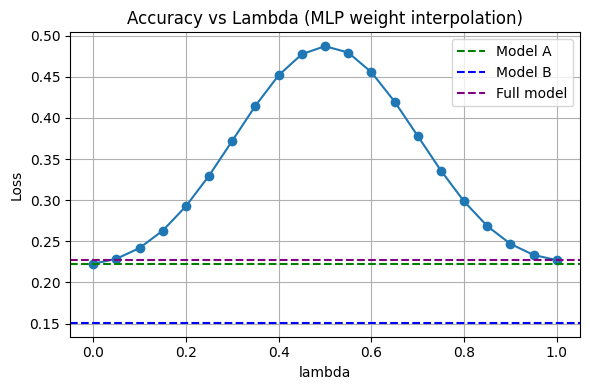

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(lambdas, merged_naive_loss, marker='o')
plt.axhline(LossA, color='green', linestyle='--', label="Model A")
plt.axhline(LossFull, color='blue', linestyle='--', label="Model B")
plt.axhline(LossB, color='purple', linestyle='--', label="Full model")
plt.title("Accuracy vs Lambda (MLP weight interpolation)")
plt.xlabel("lambda")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [23]:
### This will take in the weights in tensors, make them arrays
def compute_similarity(W_A, W_B):
    A = np.asarray(W_A)
    B = np.asarray(W_B)
    return A @ B.T

In [24]:
def match_neurons_1layer(WA, WB):
    """
    One-hidden-layer neuron matching.

    WA, WB: numpy arrays of shape (h, d)
            rows = neuron weight vectors

    Returns:
        P : permutation matrix (h x h)
    """
    # Compute neuron-to-neuron similarity matrix
    # S[i,j] = <w_i^A, w_j^B>
    S = WA@WB.T

    # Solve linear assignment (maximize similarity)
    cost = -S
    row_ind, col_ind = linear_sum_assignment(cost)

    h = WA.shape[0]
    P = np.zeros((h, h), dtype=np.float32)
    P[row_ind, col_ind] = 1.0

    return P

In [25]:
WA = np.asarray(stateA['fc1.weight'])
WB = np.asarray(stateB['fc1.weight'])

P = match_neurons_1layer(WA, WB)

In [26]:
# Get original state_dict of model B
stateB = modelB.state_dict()

# --- Permute fc1.weight (rows) ---
W1_B = stateB['fc1.weight'].numpy()      # (512, 784)
W1_B_perm = P @ W1_B                            # permute rows

# --- Permute fc2.weight (columns) ---
W2_B = stateB['fc2.weight'].numpy()      # (10, 512)
W2_B_perm = W2_B @ P.T                          # permute columns

# --- Build new state_dict ---
stateB_perm = {}

for k, v in stateB.items():
    if k == 'fc1.weight':
        stateB_perm[k] = torch.from_numpy(W1_B_perm).float()
    elif k == 'fc2.weight':
        stateB_perm[k] = torch.from_numpy(W2_B_perm).float()
    else:
        # copy everything else unchanged (biases if they exist)
        stateB_perm[k] = v.clone()


In [27]:
modelB_perm = MLP()
modelB_perm.load_state_dict(stateB_perm)


<All keys matched successfully>

In [38]:
lambdas = np.linspace(0, 1, 21)
merged_permuted_loss = []
for lam in lambdas:
    s2 = interp_states(stateA, stateB_perm, lam)
    merged_permuted_loss.append(evaluate_model_state_dict(s2))

### Loss Barriers

In [40]:
### Loss Barriers
naive_loss_barrier = max(merged_naive_loss) - 0.5 * (LossA + LossB)
permuted_loss_barrier = max(merged_permuted_loss) - 0.5 * (LossA + LossB)

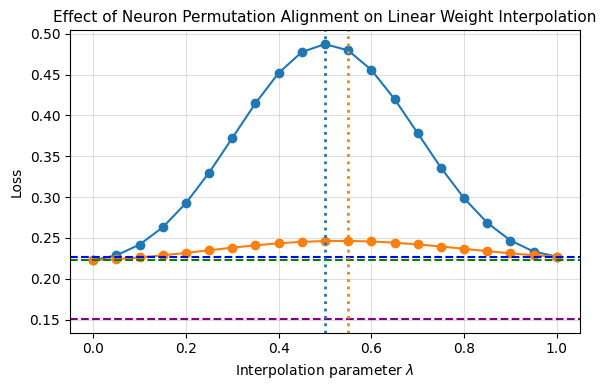

In [41]:
plt.figure(figsize=(6,4))

lambda_naive_barrier = lambdas[np.argmax(merged_naive_loss)]
lambda_perm_barrier  = lambdas[np.argmax(merged_permuted_loss)]

plt.plot(lambdas, merged_naive_loss,marker='o', label='Naive interpolation')

plt.plot(lambdas, merged_permuted_loss,marker='o', label='Permutation-aligned interpolation')

plt.axhline(LossA,color='green', linestyle='--', linewidth=1.5, label='Model A')

plt.axhline(LossB,color='blue', linestyle='--', linewidth=1.5, label='Model B')

plt.axhline(LossFull, color='purple', linestyle='--', linewidth=1.5, label='Model trained on full data')

plt.axvline(lambda_naive_barrier, color='tab:blue', linestyle=':',
            linewidth=2, label='Naive loss barrier')

plt.axvline(lambda_perm_barrier, color='tab:orange', linestyle=':',
            linewidth=2, label='Permuted loss barrier')

plt.title('Effect of Neuron Permutation Alignment on Linear Weight Interpolation',fontsize=11)

plt.xlabel('Interpolation parameter $\\lambda$', fontsize=10)
plt.ylabel('Loss', fontsize=10)

#plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()

### Ensemble

In [45]:
def ensemble_lambda_logprobs(x, modelA, modelB, lam):
    """
    λ-weighted ensemble of two models in prediction space.

    Returns log-probabilities.
    """
    with torch.no_grad():
        logpA = modelA(x)          # log p_A
        logpB = modelB(x)          # log p_B

        pA = logpA.exp()
        pB = logpB.exp()

        p_mix = (1 - lam) * pA + lam * pB
        logp_mix = torch.log(p_mix + 1e-12)

    return logp_mix

In [46]:
def evaluate_lambda_ensemble_loss(modelA, modelB, test_loader, lam):
    criterion = nn.NLLLoss(reduction='sum')
    total_loss = 0.0
    total = 0

    for x, y in test_loader:
        logp = ensemble_lambda_logprobs(x, modelA, modelB, lam)
        loss = criterion(logp, y)
        total_loss += loss.item()
        total += y.size(0)

    return total_loss / total


In [47]:
lambdas = np.linspace(0, 1, 21)
ensemble_losses = []

modelA.eval()
modelB.eval()

for lam in lambdas:
    L = evaluate_lambda_ensemble_loss(modelA, modelB, test_loader, lam)
    ensemble_losses.append(L)

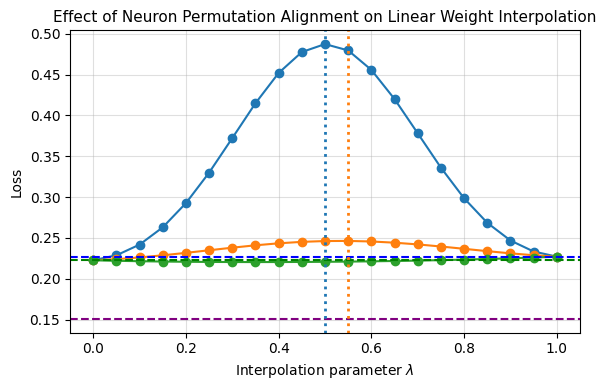

In [48]:
plt.figure(figsize=(6,4))

lambda_naive_barrier = lambdas[np.argmax(merged_naive_loss)]
lambda_perm_barrier  = lambdas[np.argmax(merged_permuted_loss)]

plt.plot(lambdas, merged_naive_loss,marker='o', label='Naive interpolation')

plt.plot(lambdas, merged_permuted_loss,marker='o', label='Permutation-aligned interpolation')

plt.plot(lambdas, ensemble_losses,'-o', label='Ensembling')


plt.axhline(LossA,color='green', linestyle='--', linewidth=1.5, label='Model A')

plt.axhline(LossB,color='blue', linestyle='--', linewidth=1.5, label='Model B')

plt.axhline(LossFull, color='purple', linestyle='--', linewidth=1.5, label='Model trained on full data')

plt.axvline(lambda_naive_barrier, color='tab:blue', linestyle=':',
            linewidth=2, label='Naive loss barrier')

plt.axvline(lambda_perm_barrier, color='tab:orange', linestyle=':',
            linewidth=2, label='Permuted loss barrier')

plt.title('Effect of Neuron Permutation Alignment on Linear Weight Interpolation',fontsize=11)

plt.xlabel('Interpolation parameter $\\lambda$', fontsize=10)
plt.ylabel('Loss', fontsize=10)

#plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()

### Loss Landscape

In [ ]:
def flatten_state(state_dict):
    flat = []
    meta = []
    #### We are generating a flattened array of all params so we can treat final parameters as somewhat pointwise
    for k, v in state_dict.items():
        #### k is the different layer keys. i.e fc1.weight etc, v is the tensor of params weights and biases
        #### we convert from tensor to flat array
        arr = v.detach().numpy().ravel()
        flat.append(arr)
        ### store in meta to build back up after. i.e back to tensor
        meta.append((k, v.shape, arr.size))
    return np.concatenate(flat), meta

def unflatten_state(vec, meta):
    d = {}
    offset = 0
    for k, shape, size in meta:
        part = vec[offset:offset+size]
        offset += size
        d[k] = torch.from_numpy(part.reshape(shape)).float()
    return d



flatA, metaA = flatten_state(stateA)
flatB, metaB = flatten_state(stateB)
flatB_perm,metaB_perm = flatten_state(stateB_perm)



# X-axis direction is defined by direction from permuted B to permuted A
u = flatB_perm - flatA
u /= np.linalg.norm(u)

# Y-axis direction defined by direction from permuted B to raw B
v = flatB_perm - flatB   # raw B → permuted B
v = v - np.dot(v, u) * u  # make orthogonal to u, in order to be an appopriate axis
v /= np.linalg.norm(v)


# Differences relative to A
delta_Braw  = flatB      - flatA
delta_Bperm = flatB_perm - flatA

# Coordinates in the (u, v) plane
### A is (0,0) is u,v plane 

Braw_x  = np.dot(delta_Braw,  u)
Braw_y  = np.dot(delta_Braw,  v)

Bperm_x = np.dot(delta_Bperm, u)
Bperm_y = np.dot(delta_Bperm, v)


# ------------------------------------------------------------
# 3. Evaluate the loss on a grid over (α, β)
# ------------------------------------------------------------
def evaluate_flat_vector(vec, meta):
    """Convert vec -> model -> accuracy & loss."""
    state = unflatten_state(vec, meta)
    model = MLP()
    model.load_state_dict(state)
    model.eval()

    total_loss = 0.0
    total_count = 0

    criterion = torch.nn.NLLLoss()

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            total_count += x.size(0)

    return total_loss / total_count  # average loss


alpha_min = min(0, Braw_x, Bperm_x) - 5
alpha_max = max(0, Braw_x, Bperm_x) + 5

beta_min = min(0, Braw_y, Bperm_y) - 5
beta_max = max(0, Braw_y, Bperm_y) + 5


##### Saved run again if anything is changed


# # Grid definition
# G = 10
# alphas = np.linspace(alpha_min, alpha_max, G)
# betas  = np.linspace(beta_min, beta_max, G)


# loss_surface = np.zeros((G, G))

# print("Evaluating 2D loss surface...")

# for i, a in enumerate(alphas):
#     for j, b in enumerate(betas):
#         theta = flatA + a * u + b * v     # point in 2D plane
#         loss_surface[i, j] = evaluate_flat_vector(theta, metaA)
#         print(f"({i},{j}) loss={loss_surface[i,j]:.4f}")

# np.save("loss_surface.npy", loss_surface)
# np.save("alphas.npy", alphas)
# np.save("betas.npy", betas)

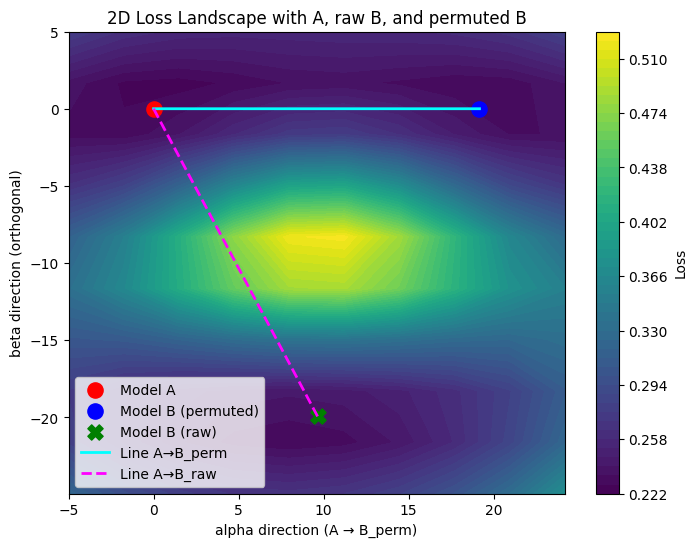

In [ ]:
plt.figure(figsize=(8,6))

# Importing previous saved values
loss_surface = np.load("loss_surface.npy")
alphas = np.load("alphas.npy")
betas = np.load("betas.npy")

CS = plt.contourf(alphas, betas, loss_surface.T, levels=50, cmap='viridis')
plt.colorbar(label="Loss")

# Plot Model A
plt.scatter(0, 0, c='red', s=120, marker='o', label='Model A')

# Plot permuted Model B (this is the aligned one)
plt.scatter(Bperm_x, Bperm_y, c='blue', s=120, marker='o', label='Model B (permuted)')

# Plot raw Model B (misaligned)
plt.scatter(Braw_x, Braw_y, c='green', s=120, marker='X', label='Model B (raw)')

# Draw line A → B_perm
plt.plot([0, Bperm_x], [0, Bperm_y],
         color='cyan', linestyle='-', linewidth=2,
         label='Line A→B_perm')

# Draw line A → B_raw
plt.plot([0, Braw_x], [0, Braw_y],
         color='magenta', linestyle='--', linewidth=2,
         label='Line A→B_raw')


plt.xlabel("alpha direction (A → B_perm)")
plt.ylabel("beta direction (orthogonal)")
plt.title("2D Loss Landscape with A, raw B, and permuted B")
plt.legend()

plt.show()

### Bezier curve  *** To investigate. - Interesting

In [49]:
class QuadraticBezier(nn.Module):
    def __init__(self, theta_A, theta_B):
        super().__init__()
        # Endpoints are fixed
        self.register_buffer("theta_A", torch.from_numpy(theta_A).float())
        self.register_buffer("theta_B", torch.from_numpy(theta_B).float())

        # Control point is trainable
        theta_C_init = 0.5 * (theta_A + theta_B)
        self.theta_C = nn.Parameter(torch.from_numpy(theta_C_init).float())

    def forward(self, t):
        """
        t: tensor of shape (batch,)
        returns: flattened parameter vectors theta(t)
        """
        t = t.view(-1, 1)
        return (
            (1 - t)**2 * self.theta_A
            + 2 * t * (1 - t) * self.theta_C
            + t**2 * self.theta_B
        )


In [50]:
def bezier_loss(curve, meta, batch_size=5):
    ts = torch.rand(batch_size)
    loss = 0.0
    for t in ts:
        theta_t = curve(t.unsqueeze(0))[0].detach().cpu().numpy()
        loss += evaluate_flat_vector(theta_t, meta)
    return loss / batch_size


In [53]:
curve = QuadraticBezier(flatA, flatB_perm)
optimizer = torch.optim.Adam([curve.theta_C], lr=1e-2)

num_steps = 10

for step in range(num_steps):
    optimizer.zero_grad()
    loss = bezier_loss(curve, metaA)
    loss_tensor = torch.tensor(loss, requires_grad=True)
    loss_tensor.backward()
    optimizer.step()

    if step % 2 == 0:
        print(f"Step {step:03d} | Curve loss ≈ {loss:.4f}")


Step 000 | Curve loss ≈ 0.2361
Step 002 | Curve loss ≈ 0.2374
Step 004 | Curve loss ≈ 0.2309
Step 006 | Curve loss ≈ 0.2383
Step 008 | Curve loss ≈ 0.2381


In [55]:
lambdas = np.linspace(0, 1, 21)

bezier_losses = []

for lam in lambdas:

    # Bezier path
    with torch.no_grad():
        theta_bez = curve(torch.tensor([lam]))[0].cpu().numpy()
    bezier_losses.append(evaluate_flat_vector(theta_bez, metaA))


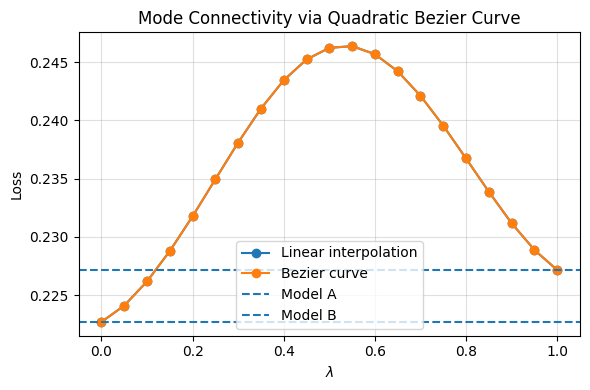

In [60]:
plt.figure(figsize=(6,4))

plt.plot(lambdas, merged_permuted_loss, '-o', label='Linear interpolation')
plt.plot(lambdas, bezier_losses, '-o', label='Bezier curve')

plt.axhline(LossA, linestyle='--', label='Model A')
plt.axhline(LossB, linestyle='--', label='Model B')

plt.xlabel(r'$\lambda$')
plt.ylabel('Loss')
plt.title('Mode Connectivity via Quadratic Bezier Curve')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


### OT works very poorly, not sure on my implementation but it doesn't work well anyway

In [92]:
def cost_matrix(WA, WB):
    A2 = np.sum(WA**2, axis=1, keepdims=True)
    B2 = np.sum(WB**2, axis=1, keepdims=True).T
    return A2 + B2 - 2 * WA @ WB.T


In [93]:
import ot

def normalize_rows(W, eps=1e-12):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    return W / (norms + eps)



def match_neurons_1layer_ot(WA, WB, reg=1e-2, normalize=True):
    """
    Optimal Transport matching for one hidden layer.

    WA, WB: numpy arrays (h, d)
    Returns:
        T : transport matrix (h x h)
    """
    if normalize:
        WA = normalize_rows(WA)
        WB = normalize_rows(WB)

    h = WA.shape[0]

    # Squared Euclidean cost on normalized rows
    C = cost_matrix(WA, WB)

    # uniform marginals
    mu = np.ones(h) / h
    nu = np.ones(h) / h

    # Sinkhorn solver
    T = ot.sinkhorn(mu, nu, C, reg)

    return T



In [103]:
WA = np.asarray(stateA['fc1.weight'])
WB = np.asarray(stateB['fc1.weight'])

T = match_neurons_1layer_ot(WA, WB)



# Get original state_dict of model B
stateB = modelB.state_dict()

# --- Permute fc1.weight (rows) ---
W1_B = stateB['fc1.weight'].numpy()      # (512, 784)
W1_B_perm_ot = T @ W1_B                            # permute rows

# --- Permute fc2.weight (columns) ---
W2_B = stateB['fc2.weight'].numpy()      # (10, 512)
W2_B_perm_ot = W2_B @ T.T                          # permute columns

# --- Build new state_dict ---
stateB_perm_ot = {}

for k, v in stateB.items():
    if k == 'fc1.weight':
        stateB_perm_ot[k] = torch.from_numpy(W1_B_perm_ot).float()
    elif k == 'fc2.weight':
        stateB_perm_ot[k] = torch.from_numpy(W2_B_perm_ot).float()
    else:
        # copy everything else unchanged (biases if they exist)
        stateB_perm_ot[k] = v.clone()

In [104]:
modelB_perm_ot = MLP()
modelB_perm_ot.load_state_dict(stateB_perm_ot)

lambdas = np.linspace(0, 1, 21)
merged_permuted_ot_loss = []
for lam in lambdas:
    s2 = interp_states(stateA, stateB_perm_ot, lam)
    merged_permuted_ot_loss.append(evaluate_model_state_dict(s2))

In [105]:
### Loss Barriers
permuted_ot_loss_barrier = max(merged_permuted_ot_loss) - 0.5 * (LossA + LossB)

print(permuted_ot_loss_barrier)
print(permuted_loss_barrier)

2.0776605884552
0.02146029510498046


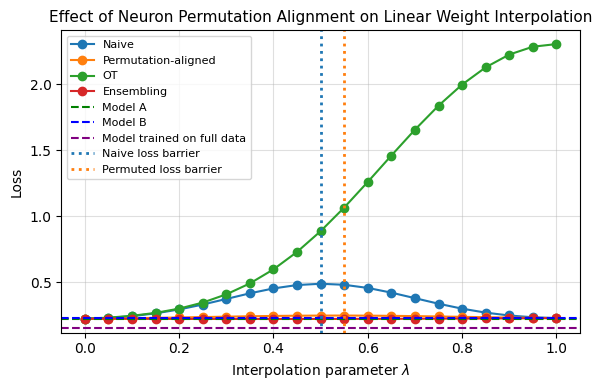

In [106]:

plt.figure(figsize=(6,4))

lambda_naive_barrier = lambdas[np.argmax(merged_naive_loss)]
lambda_perm_barrier  = lambdas[np.argmax(merged_permuted_loss)]

plt.plot(lambdas, merged_naive_loss,marker='o', label='Naive')

plt.plot(lambdas, merged_permuted_loss,marker='o', label='Permutation-aligned')

plt.plot(lambdas, merged_permuted_ot_loss,'-o', label='OT')

plt.plot(lambdas, ensemble_losses,'-o', label='Ensembling')

plt.axhline(LossA,color='green', linestyle='--', linewidth=1.5, label='Model A')

plt.axhline(LossB,color='blue', linestyle='--', linewidth=1.5, label='Model B')

plt.axhline(LossFull, color='purple', linestyle='--', linewidth=1.5, label='Model trained on full data')

plt.axvline(lambda_naive_barrier, color='tab:blue', linestyle=':',
            linewidth=2, label='Naive loss barrier')

plt.axvline(lambda_perm_barrier, color='tab:orange', linestyle=':',
            linewidth=2, label='Permuted loss barrier')

plt.title('Effect of Neuron Permutation Alignment on Linear Weight Interpolation',fontsize=11)

plt.xlabel('Interpolation parameter $\\lambda$', fontsize=10)
plt.ylabel('Loss', fontsize=10)

plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.tight_layout()

plt.show()